In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint
from services.db import MongoDB_one_zero_four


plt.rcParams['font.family'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

pd.set_option("display.max_rows", 15)
pd.set_option("display.max_columns", 10)
pd.set_option("display.width", 100)

In [2]:
db = MongoDB_one_zero_four()

condition = {"header.jobName": {"$regex": "python", "$options": "i"}}
projection = {"header": 1, "condition": 1, "_id": 0}
result = db.select_from_bronze(condition, projection)

Missing environment variables: ['mongo_host', 'cluster']


ValueError: Missing environment variables: ['mongo_host', 'cluster']

In [ ]:
condition2 = {"header.jobName": {"$not": {"$regex": "python", "$options": "i"}}}
result2 = db.select_from_bronze(condition2, projection)

In [ ]:
test = []
for row in result:
    data = row["condition"]["specialty"]
    test.append(data)

pprint(test)

[[{'code': '12001002016', 'description': 'Github'},
  {'code': '12001003045', 'description': 'Python'},
  {'code': '12001003086', 'description': 'PyTorch'},
  {'code': '12001002018', 'description': 'Git'},
  {'code': '12001001007', 'description': 'Linux'}],
 [{'code': '12001003045', 'description': 'Python'},
  {'code': '12001006027', 'description': 'XML'},
  {'code': '12001001020', 'description': 'Shell'},
  {'code': '12001002017', 'description': 'Jenkins'},
  {'code': '12001003009', 'description': 'C#'},
  {'code': '12001003010', 'description': 'C++'},
  {'code': '12001005023', 'description': 'AWS'}],
 [{'code': '12001002017', 'description': 'Jenkins'},
  {'code': '12001003045', 'description': 'Python'},
  {'code': '12001003097', 'description': 'LLM'},
  {'code': '12001002018', 'description': 'Git'}],
 [{'code': '12001003045', 'description': 'Python'},
  {'code': '12001006013', 'description': 'HTML'},
  {'code': '12001006017', 'description': 'JavaScript'},
  {'code': '12001006030', 'd

In [ ]:
"""
轉換成 df 時是以每個 list 作為一個 column, 所以 df 是以 0, 1, ... list index 作為 col name, 
stack 之後因為 series 只有一行, 所以變成row[row] 的格式? 這種格式經過 df.to_list() 會以[row[row], row[row]] 這樣被拉平? 
會像是 [{}, {}, {}]? 有點神奇, 經過這些操作後撫平了一層巢狀結構
"""
"""
處理這種結構: [[dict, dict], [dict, dict], [dict, dict]]
"""
df = pd.DataFrame(test)
series = df.stack()
df_clean = pd.DataFrame(series.to_list())
print(df_clean)

# print("------------")
# series = pd.Series(test)
# print(series)

            code description
0    12001002016      Github
1    12001003045      Python
2    12001003086     PyTorch
3    12001002018         Git
4    12001001007       Linux
..           ...         ...
322  12001003045      Python
323  12001005023         AWS
324  12001006013        HTML
325  12001006017  JavaScript
326  12001006032         CSS

[327 rows x 2 columns]


In [ ]:
print(f"total:{df_clean["description"].count()}")
print("--------------")
a = df_clean["description"].value_counts()
x = 2
mask = a > x
tool_count_gt_five = a[mask]
# desc 欄位總共有幾 row - 篩選出現次數大於 x 的工具 = 其餘出現次數小於等於 x 的 工具
other = df_clean["description"].count() - tool_count_gt_five.sum()
tool_count_gt_five["other"] = other
df = pd.DataFrame(tool_count_gt_five, columns=["count"])
df = df.sort_values(by="count", ascending=False)
print(df)

total:327
--------------
             count
description       
Python          78
other           46
Git             24
Linux           20
PostgreSQL      18
...            ...
Node.js          3
RDBMS            3
PyTorch          3
C++              3
Excel            3

[27 rows x 1 columns]


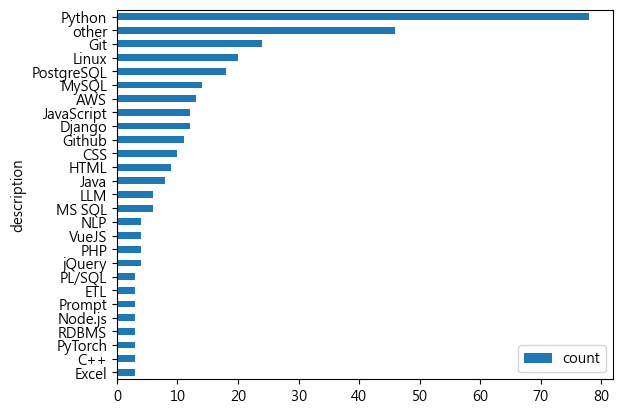

In [ ]:
ax = df.plot.barh(y='count')
ax.invert_yaxis()